In [ ]:
# Slide 7
# Image Data
# https://www.imageprocessingplace.com/DIP-3E/dip3e_book_images_downloads.htm

import cv2
import numpy as np
import matplotlib.pyplot as plt

7.1 – Computational advantage of the FFT over a direct implementation of the 1-D DFT

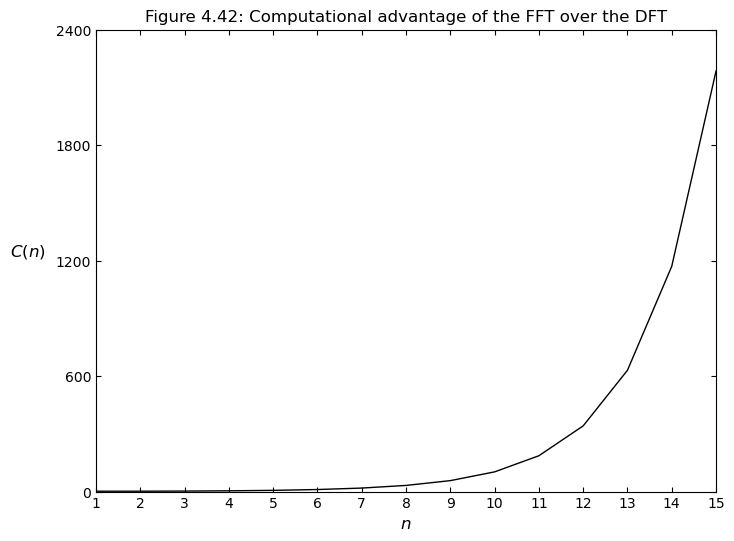

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range for n as shown in Figure 4.42
n = np.arange(1, 16)
N = 2**n

# Calculate the computational advantage C(n)
# C(n) = (Direct DFT Operations) / (FFT Operations)
# C(n) = N^2 / (N * log2(N)) = N / n
c_n = N / n

# Plotting the graph to match Figure 4.42
plt.figure(figsize=(8, 6))
plt.plot(n, c_n, color='black', linewidth=1)

# Formatting to match the textbook style
plt.xlabel('$n$', fontsize=12)
plt.ylabel('$C(n)$', rotation=0, fontsize=12, labelpad=20)
plt.title("Figure 4.42: Computational advantage of the FFT over the DFT")
plt.xlim(1, 15)
plt.ylim(0, 2400)
plt.xticks(np.arange(1, 16))
plt.yticks(np.arange(0, 2401, 600))
plt.grid(False)

# Make the plot look like a textbook figure (ticks inside)
plt.tick_params(direction='in', top=True, right=True)

plt.show()

7.2 – 2D Convolution in frequency domain WITHOUT padding, demonstrating the wrap-around (aliasing) effect

[ WARN:0@0.594] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@0.594] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@0.594] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@0.594] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@0.594] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@0.594] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@0.594] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@0.594] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

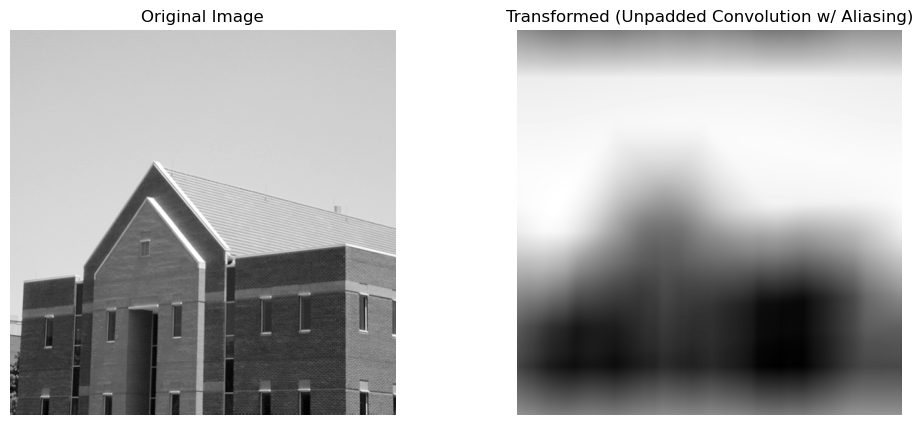

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = 'DIP3E_Original_Images_CH04/Fig0438(a)(bld_600by600).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

M, N = img.shape

# Create a large box blur filter of size 150x150, but DO NOT pad the image
filter_size = 150
h = np.ones((filter_size, filter_size), dtype=np.float64) / (filter_size**2)

# Pad filter to match image size (M, N) - NO EXTRA PADDING FOR CONVOLUTION
h_padded = np.zeros((M, N), dtype=np.float64)
h_padded[:filter_size, :filter_size] = h

# Shift filter to center to avoid translation
h_padded = np.roll(h_padded, -filter_size//2, axis=0)
h_padded = np.roll(h_padded, -filter_size//2, axis=1)

# Frequency domain multiplication
F = np.fft.fft2(img)
H = np.fft.fft2(h_padded)
G = F * H
img_aliased = np.real(np.fft.ifft2(G))

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_aliased, cmap='gray')
plt.title("Transformed (Unpadded Convolution w/ Aliasing)")
plt.axis('off')
plt.show()

7.3 – 2D Convolution in frequency domain WITH proper zero-padding to eliminate the aliasing effect

[ WARN:0@0.775] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@0.775] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@0.775] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@0.775] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@0.775] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@0.775] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@0.775] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@0.775] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

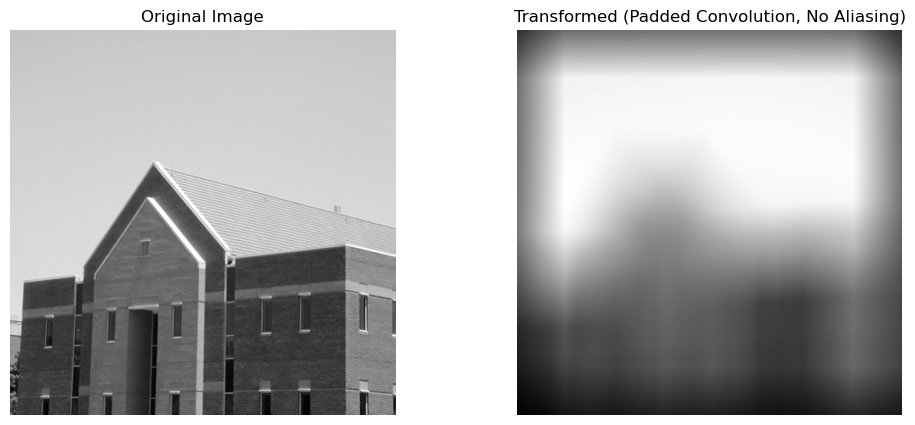

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = 'DIP3E_Original_Images_CH04/Fig0438(a)(bld_600by600).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

M, N = img.shape
filter_size = 150
h = np.ones((filter_size, filter_size), dtype=np.float64) / (filter_size**2)

# Proper padding sizes to avoid aliasing: P >= M + filter_M - 1, Q >= N + filter_N - 1
P = M + filter_size - 1
Q = N + filter_size - 1

# Pad image and filter to P x Q
img_padded = np.zeros((P, Q), dtype=np.float64)
img_padded[:M, :N] = img

h_padded = np.zeros((P, Q), dtype=np.float64)
h_padded[:filter_size, :filter_size] = h

# Center the filter
h_padded = np.roll(h_padded, -filter_size//2, axis=0)
h_padded = np.roll(h_padded, -filter_size//2, axis=1)

# Frequency domain convolution
F = np.fft.fft2(img_padded)
H = np.fft.fft2(h_padded)
G = F * H
img_filtered_padded = np.real(np.fft.ifft2(G))

# Crop back to original size M x N
img_no_aliasing = img_filtered_padded[:M, :N]

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_no_aliasing, cmap='gray')
plt.title("Transformed (Padded Convolution, No Aliasing)")
plt.axis('off')
plt.show()

7.4 – Frequency spectrum of aperiodic f(x,y) WITHOUT zero-padding and WITHOUT centering

[ WARN:0@0.986] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@0.986] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@0.986] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@0.986] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@0.986] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@0.986] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@0.986] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@0.986] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

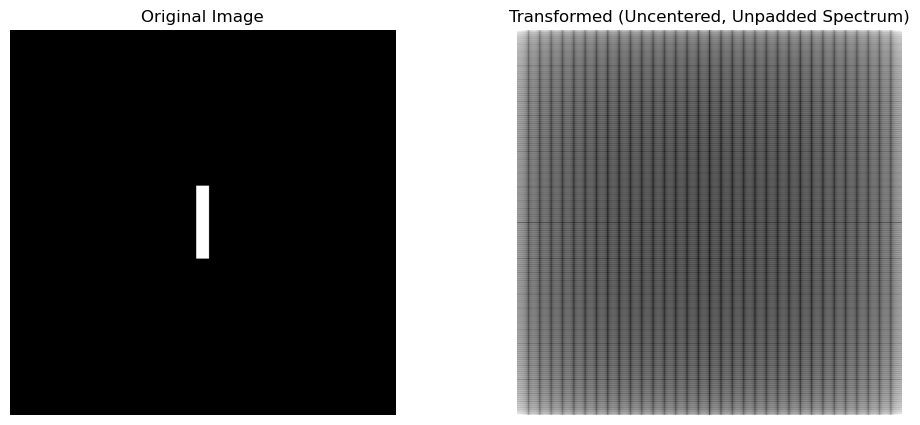

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = 'DIP3E_Original_Images_CH04/Fig0424(a)(rectangle).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Compute FFT directly without padding or centering shift
F = np.fft.fft2(img)
magnitude_spectrum = np.log(1 + np.abs(F))

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Transformed (Uncentered, Unpadded Spectrum)")
plt.axis('off')
plt.show()

7.5 – Frequency spectrum of aperiodic f(x,y) WITH zero-padding and WITH centering (-1)^(x+y)

[ WARN:0@1.192] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@1.192] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@1.192] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@1.192] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@1.192] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@1.192] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@1.192] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@1.192] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

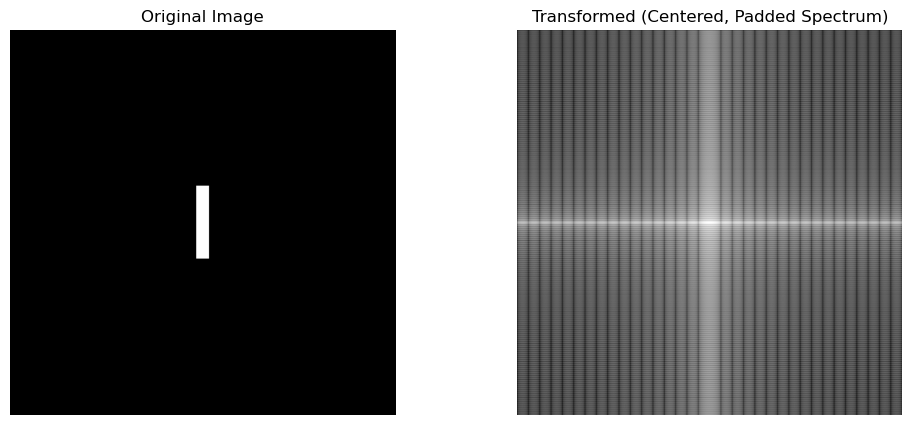

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = 'DIP3E_Original_Images_CH04/Fig0424(a)(rectangle).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

M, N = img.shape
P, Q = 2 * M, 2 * N

# Pad the image
img_padded = np.zeros((P, Q), dtype=np.float64)
img_padded[:M, :N] = img

# Multiply by (-1)^(x+y) to center the spectrum
x = np.arange(P)
y = np.arange(Q)
X, Y = np.meshgrid(y, x)
img_centered = img_padded * ((-1)**(X + Y))

# Compute FFT
F = np.fft.fft2(img_centered)
magnitude_spectrum_centered = np.log(1 + np.abs(F))

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(magnitude_spectrum_centered, cmap='gray')
plt.title("Transformed (Centered, Padded Spectrum)")
plt.axis('off')
plt.show()

7.6 – Padding and convolution process showing the full padded domain output vs the final cropped output

[ WARN:0@1.874] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@1.874] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@1.874] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@1.874] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@1.874] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@1.874] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@1.874] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@1.874] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

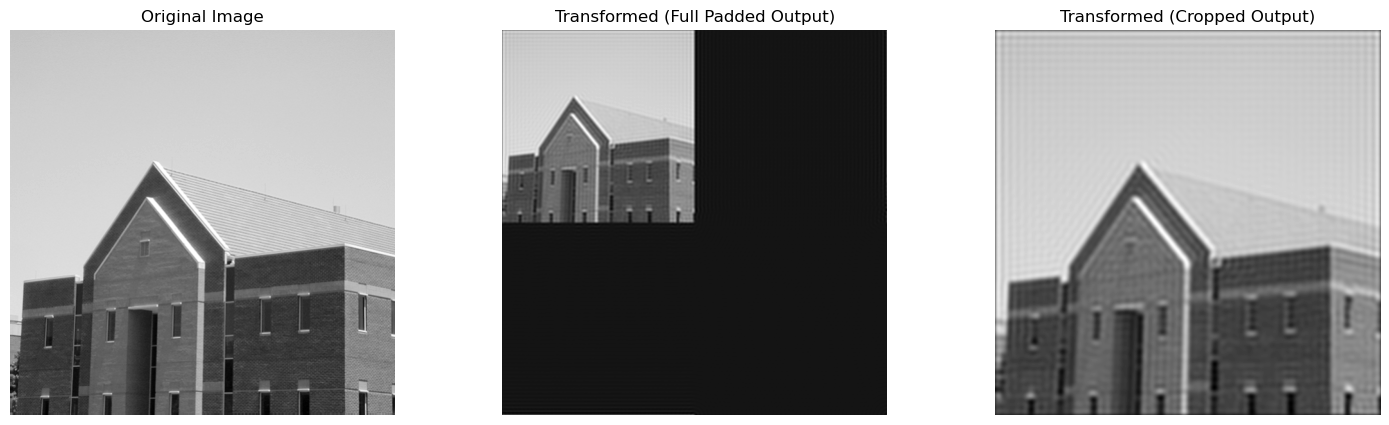

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = 'DIP3E_Original_Images_CH04/Fig0438(a)(bld_600by600).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

M, N = img.shape
P, Q = 2 * M, 2 * N  # Double the size for standard safe padding

img_padded = np.zeros((P, Q), dtype=np.float64)
img_padded[:M, :N] = img

# Simple Ideal Low Pass Filter in padded frequency domain
u = np.arange(P)
v = np.arange(Q)
u, v = np.meshgrid(v, u)
u = u - P/2
v = v - Q/2
D = np.sqrt(u**2 + v**2)

H = np.zeros((P, Q), dtype=np.float64)
H[D <= 100] = 1.0  # D0 = 100

# Shift image, FFT, Multiply, IFFT, unshift
x = np.arange(P)
y = np.arange(Q)
X, Y = np.meshgrid(y, x)
img_centered = img_padded * ((-1)**(X + Y))

F = np.fft.fft2(img_centered)
G = F * H
img_out_padded = np.real(np.fft.ifft2(G)) * ((-1)**(X + Y))

# Cropped output
img_out_cropped = img_out_padded[:M, :N]

# Plotting
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_out_padded, cmap='gray')
plt.title("Transformed (Full Padded Output)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_out_cropped, cmap='gray')
plt.title("Transformed (Cropped Output)")
plt.axis('off')
plt.show()

7.7 – Frequency domain template matching (correlation) and horizontal profile of the maximum match

[ WARN:0@2.206] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@2.206] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@2.206] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@2.206] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@2.206] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@2.206] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@2.206] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@2.206] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

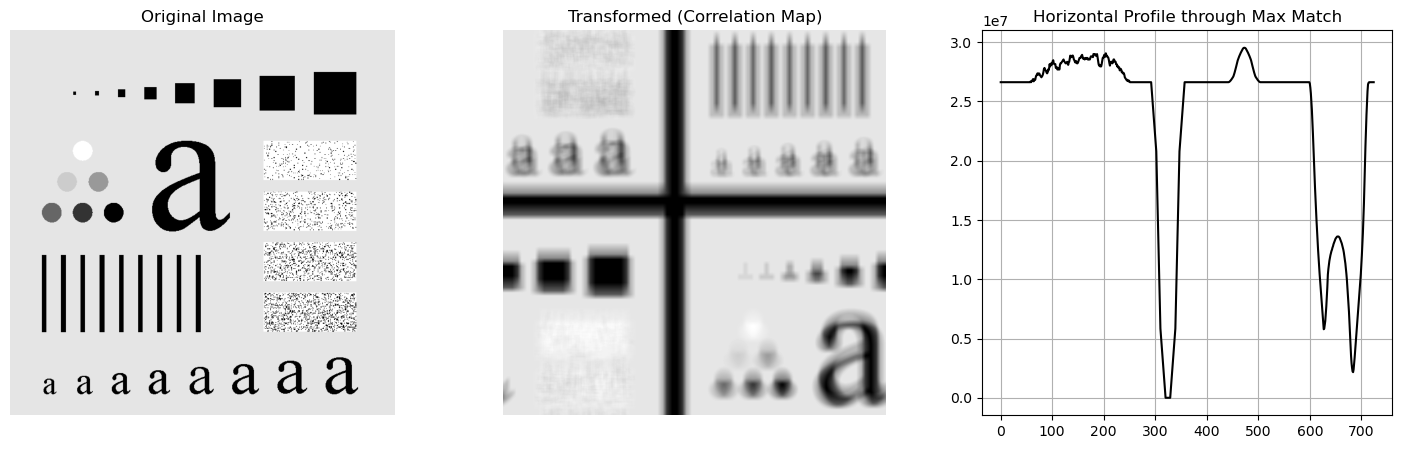

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = 'DIP3E_Original_Images_CH04/Fig0441(a)(characters_test_pattern).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Create a synthetic template matching T
template = np.zeros((42, 38), dtype=np.float64)
template[5:15, 5:33] = 255  # Top bar of T
template[15:37, 15:23] = 255 # Stem of T

A, B = img.shape
C, D = template.shape

# Padding dimensions for correlation P = A+C-1, Q = B+D-1
P = A + C - 1
Q = B + D - 1

f_padded = np.zeros((P, Q), dtype=np.float64)
f_padded[:A, :B] = img

w_padded = np.zeros((P, Q), dtype=np.float64)
w_padded[:C, :D] = template

# Correlation theorem: F(u,v) * conj(W(u,v))
F = np.fft.fft2(f_padded)
W = np.fft.fft2(w_padded)
Correlation_freq = F * np.conj(W)

# Inverse FFT and shift back
correlation_img = np.real(np.fft.ifft2(Correlation_freq))
correlation_img = np.fft.fftshift(correlation_img)

# Find coordinates of highest correlation value
max_val_idx = np.unravel_index(np.argmax(correlation_img), correlation_img.shape)
y_max, x_max = max_val_idx

# Extract 1D horizontal profile through the highest value
profile_line = correlation_img[y_max, :]

# Plotting
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(correlation_img, cmap='gray')
plt.title("Transformed (Correlation Map)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.plot(profile_line, color='black')
plt.title("Horizontal Profile through Max Match")
plt.grid(True)
plt.show()